In [110]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import warnings
data_dir = Path("cleaned_data")
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

yellow_taxi = spark.read.parquet(f"{data_dir / 'yellow_data.parquet'}")
yellow_taxi = yellow_taxi.filter(F.col('date') < '2026-01-01')
fhvhv_taxi = spark.read.parquet(f"{data_dir / 'fhvhv_data.parquet'}")
fhvhv_taxi = fhvhv_taxi.filter(F.col('date') < '2026-01-01')
warnings.filterwarnings("ignore", module="pyspark")
yellow_taxi.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:42:49|         138|       57.15| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [111]:
fhvhv_taxi.show(1)

+-------------------+------------+
|               date|PULocationID|
+-------------------+------------+
|2023-03-01 00:05:26|         114|
+-------------------+------------+
only showing top 1 row


In [112]:
daily_taxi_earnings = (
    yellow_taxi
    .withColumn("day", F.to_date("date"))
    .groupBy("day", "PULocationID")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy("day", "PULocationID")
)
print(daily_taxi_earnings.count())

228360


In [113]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")
geo_data.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


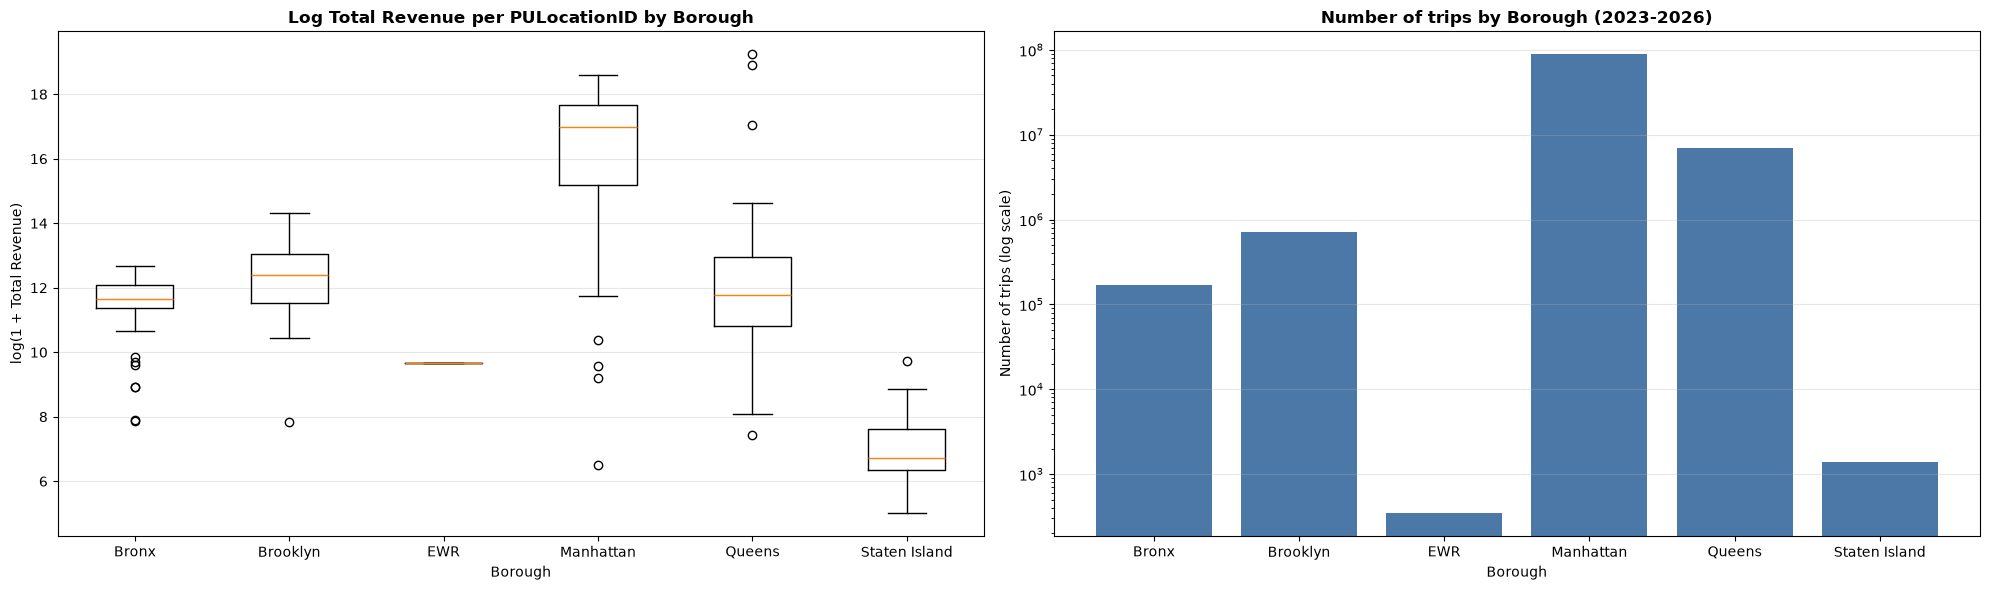

In [114]:
import matplotlib.pyplot as plt
# --------------------------------------------------
# Step 3: Total revenue for each PULocationID
# over the ENTIRE time period
# --------------------------------------------------

location_total_revenue = (
    yellow_taxi
    .groupBy("PULocationID", "Borough")
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
    .withColumn(
        "log_total_revenue",
        F.log1p("total_revenue")
    )
)


# --------------------------------------------------
# Step 4: Count number of trips for each Borough
# --------------------------------------------------

borough_trip_counts = (
    yellow_taxi
    .groupBy("Borough")
    .agg(
        F.count("*").alias("number_of_trips")
    )
    .orderBy("Borough")
)


# --------------------------------------------------
# Step 5: Convert both results to Pandas
# --------------------------------------------------

location_total_revenue_pd = location_total_revenue.toPandas()
borough_trip_counts_pd = borough_trip_counts.toPandas()


# --------------------------------------------------
# Step 6: Prepare boxplot data
# --------------------------------------------------

boroughs = sorted(
    location_total_revenue_pd["Borough"]
    .dropna()
    .unique()
)

boxplot_data = [
    location_total_revenue_pd.loc[
        location_total_revenue_pd["Borough"] == borough,
        "log_total_revenue"
    ].dropna()
    for borough in boroughs
]


# --------------------------------------------------
# Step 7: Create 1x2 subplot
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 6)
)


# ==================================================
# LEFT: Boxplot of log total revenue
# ==================================================

axes[0].boxplot(
    boxplot_data,
    tick_labels=boroughs
)

axes[0].set_title(
    "Log Total Revenue per PULocationID by Borough",
    fontweight="bold"
)

axes[0].set_xlabel("Borough")
axes[0].set_ylabel("log(1 + Total Revenue)")
axes[0].grid(axis="y", alpha=0.3)


# ==================================================
# RIGHT: Number of trips by Borough
# ==================================================

axes[1].bar(
    borough_trip_counts_pd["Borough"],
    borough_trip_counts_pd["number_of_trips"],
    color='#4C78A8'
)

axes[1].set_title(
    "Number of trips by Borough (2023-2026)",
    fontweight="bold"
)

axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Number of trips (log scale)")
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.3)


# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.tight_layout()
plt.show()

In [115]:
# create a new column called trip_volume which is the the number of trips per PULocationID per day

fhvhv_trip_volume = (
    fhvhv_taxi
    .withColumn("date", F.to_date("date"))
    .groupBy("PULocationID", "date")
    .agg(F.count("*").alias("trip_volume"))
)
fhvhv_trip_volume.show(5)

+------------+----------+-----------+
|PULocationID|      date|trip_volume|
+------------+----------+-----------+
|          50|2023-03-01|       3391|
|         223|2023-03-01|       2608|
|         248|2023-03-03|       1954|
|         247|2023-03-04|       3538|
|         109|2023-03-06|        343|
+------------+----------+-----------+
only showing top 5 rows


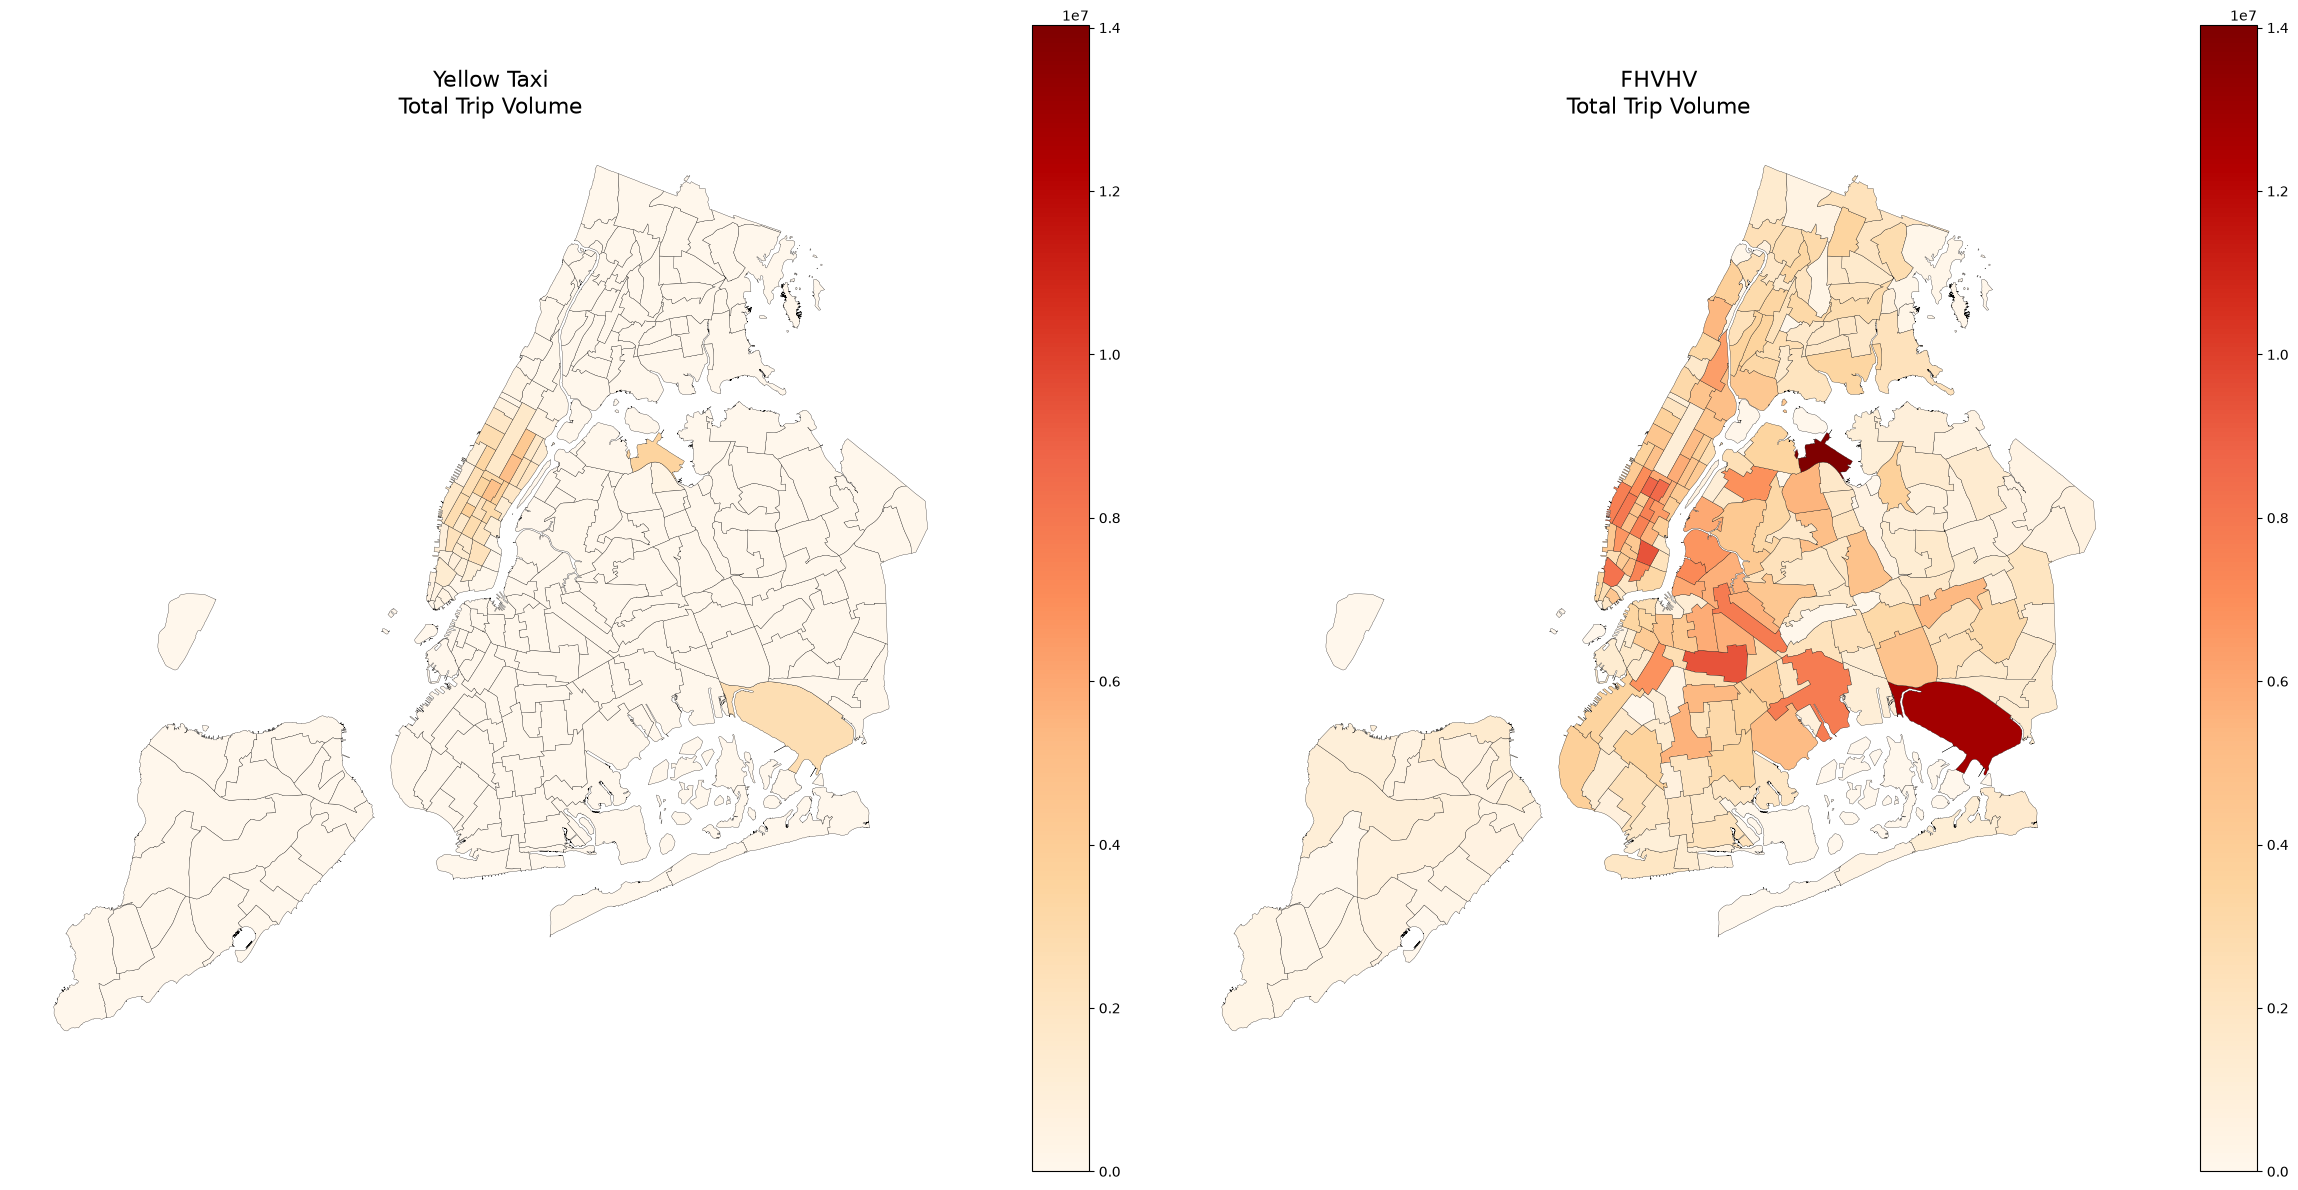

In [116]:
# ---------------------------------------------------------
# 1. Yellow Taxi: count trips across ALL dates
# ---------------------------------------------------------
yellow_total = (
    yellow_taxi
    .groupBy("PULocationID")
    .count()
    .withColumnRenamed("count", "trip_volume")
)

yellow_pd = yellow_total.toPandas()


# ---------------------------------------------------------
# 2. FHVHV: sum trip volume across ALL dates
# ---------------------------------------------------------
fhvhv_total = (
    fhvhv_trip_volume
    .groupBy("PULocationID")
    .sum("trip_volume")
    .withColumnRenamed("sum(trip_volume)", "trip_volume")
)

fhvhv_pd = fhvhv_total.toPandas()


# ---------------------------------------------------------
# 3. Load NYC Taxi Zone shapefile
# ---------------------------------------------------------
taxi_zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")

taxi_zones["LocationID"] = taxi_zones["LocationID"].astype(int)

yellow_pd["PULocationID"] = yellow_pd["PULocationID"].astype(int)
fhvhv_pd["PULocationID"] = fhvhv_pd["PULocationID"].astype(int)


# ---------------------------------------------------------
# 4. Join trip volumes to the geographic zones
# ---------------------------------------------------------
yellow_map = taxi_zones.merge(
    yellow_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

fhvhv_map = taxi_zones.merge(
    fhvhv_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

# Zones with no trips get 0
yellow_map["trip_volume"] = yellow_map["trip_volume"].fillna(0)
fhvhv_map["trip_volume"] = fhvhv_map["trip_volume"].fillna(0)


# ---------------------------------------------------------
# 5. SAME color scale for both maps
# ---------------------------------------------------------
vmin = min(
    yellow_map["trip_volume"].min(),
    fhvhv_map["trip_volume"].min()
)

vmax = max(
    yellow_map["trip_volume"].max(),
    fhvhv_map["trip_volume"].max()
)


# ---------------------------------------------------------
# 6. Create side-by-side choropleth maps
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 12)
)

# Yellow Taxi
yellow_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    missing_kwds={"color": "lightgrey"}
)

axes[0].set_title(
    "Yellow Taxi\nTotal Trip Volume",
    fontsize=16
)
axes[0].axis("off")


# FHVHV
fhvhv_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    missing_kwds={"color": "lightgrey"}
)

axes[1].set_title(
    "FHVHV\nTotal Trip Volume",
    fontsize=16
)
axes[1].axis("off")


plt.tight_layout()
plt.show()

# Forecasting trip volume: The problem
Since we won't have trip volume for For-Hire vehicles available at prediction time, we must forecast the trip volume for a particular day using historical data. 

As we see from the graph below, the total trip volume for FHVs follows a very clear seasonal pattern which will allow us to construct a model that can give a reasonably accurate forecast of trip volume by continuing this pattern.

Note that we are assuming that this forecast will be accurate enough for our analysis. In reality it is an assumption made to simplify our forecasting work since it is not the main focus of this research. 

A recommendation here would be to seek ways to improve this trip volume forecasting system for more accurate predictions of revenue earnings at a particular zone on a particular day. 

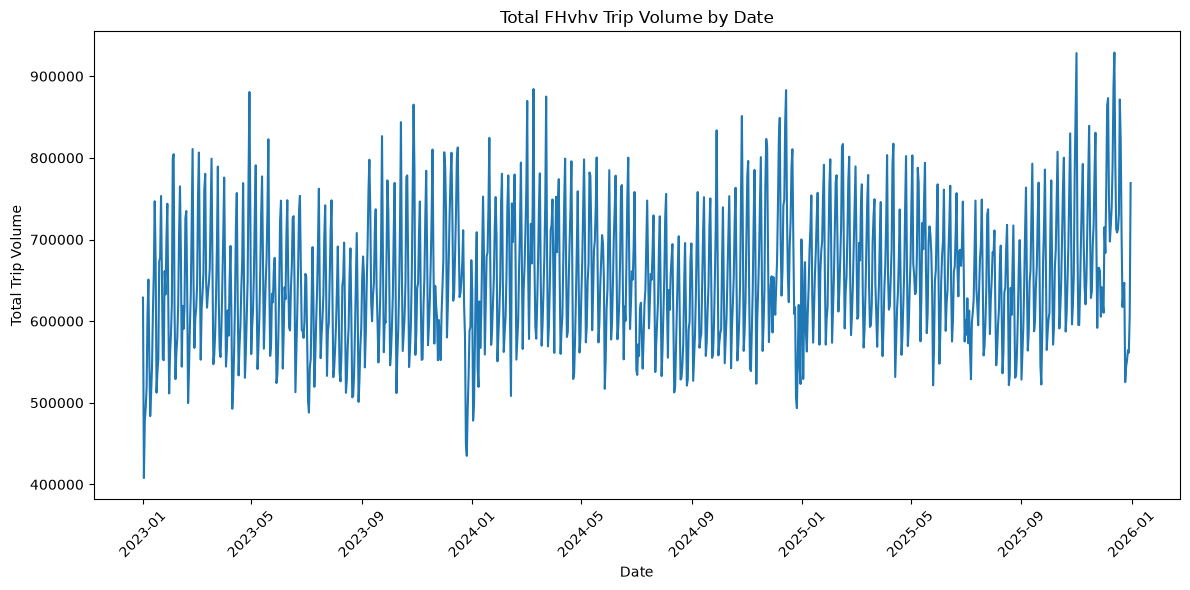

In [ ]:
daily_trip_volume = (
    fhvhv_trip_volume
    .groupBy("date")
    .agg(F.sum("trip_volume").alias("total_trip_volume"))
    .orderBy("date")
)
pdf = daily_trip_volume.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(pdf["date"], pdf["total_trip_volume"])
plt.xlabel("Date")
plt.ylabel("Total Trip Volume")
plt.title("Total FHVHV Trip Volume by Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [118]:
from utils import add_stations
yellow_data_with_stations = add_stations(yellow_total, spark)

In [119]:
daily_taxi_earnings = add_stations(daily_taxi_earnings, spark)
daily_taxi_earnings.show(5)

+----------+------------+------------------+------------+
|       day|PULocationID|      total_amount|num_stations|
+----------+------------+------------------+------------+
|2023-05-01|          95|            381.71|           3|
|2023-05-05|         253|             66.24|           0|
|2023-05-06|         229|43226.779999999875|           1|
|2023-05-09|         235|             203.7|           2|
|2023-05-12|         219|414.20000000000005|           0|
+----------+------------+------------------+------------+
only showing top 5 rows


In [120]:
# Create a Python dictionary from GeoPandas
borough_mapping = dict(
    zip(geo_data["LocationID"], geo_data["borough"])
)

# Create a Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for location_id, borough in borough_mapping.items()
        for item in (F.lit(int(location_id)), F.lit(borough))
    ]
)

# Add Borough column
daily_taxi_earnings_with_station = daily_taxi_earnings.withColumn(
    "Borough",
    mapping_expr[F.col("PULocationID")]
)

In [121]:
daily_taxi_earnings_with_station.show(2)

+----------+------------+------------+------------+-------+
|       day|PULocationID|total_amount|num_stations|Borough|
+----------+------------+------------+------------+-------+
|2023-05-01|          95|      381.71|           3| Queens|
|2023-05-05|         253|       66.24|           0| Queens|
+----------+------------+------------+------------+-------+
only showing top 2 rows


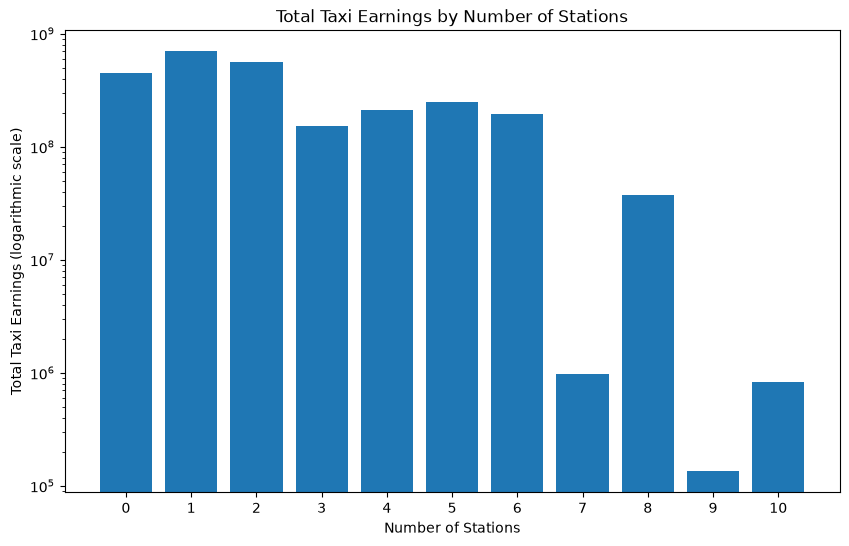

In [122]:
# Aggregate total trip volume by number of stations
plot_df = (
    daily_taxi_earnings_with_station.groupBy("num_stations")
      .agg(F.sum("total_amount").alias("total_amount"))
      .orderBy("num_stations")
)

# Convert to Pandas
pdf = plot_df.toPandas()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(
    pdf["num_stations"].astype(str),
    pdf["total_amount"]
)

plt.xlabel("Number of Stations")
plt.ylabel("Total Taxi Earnings (logarithmic scale)")
plt.title("Total Taxi Earnings by Number of Stations")
plt.yscale("log")  # Log scale for better visualization
plt.show()

In [123]:
# Create a Python dictionary from GeoPandas
borough_mapping = dict(
    zip(geo_data["LocationID"], geo_data["borough"])
)

# Create a Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for location_id, borough in borough_mapping.items()
        for item in (F.lit(int(location_id)), F.lit(borough))
    ]
)

# Add Borough column
yellow_data_with_stations = yellow_data_with_stations.withColumn(
    "Borough",
    mapping_expr[F.col("PULocationID")]
)

## Testing for association between `num_stations` and `log1p(total_amount)`


In [124]:
import statsmodels.formula.api as smf
df = (
    daily_taxi_earnings_with_station
    .filter(F.col("Borough").isNotNull())
    .withColumn(
        "log_total_amount",
        F.log1p("total_amount")
    )
)
pdf = df.select(
    "Borough",
    "num_stations",
    "log_total_amount"
).toPandas()

model = smf.ols(
    "log_total_amount ~ C(num_stations) + C(Borough)",
    data=pdf
).fit()
categorical_model = smf.ols(
    "log_total_amount ~ C(Borough) + C(num_stations)",
    data=pdf
).fit(cov_type="HC3")

for param in categorical_model.params.index:
    print(
        f"{param:45s} "
        f"coef = {categorical_model.params[param]: .6f}    "
        f"p = {categorical_model.pvalues[param]:.6g}"
    )

Intercept                                     coef =  4.274918    p = 0
C(Borough)[T.Brooklyn]                        coef =  0.440316    p = 0
C(Borough)[T.EWR]                             coef = -0.476913    p = 2.10908e-23
C(Borough)[T.Manhattan]                       coef =  4.519587    p = 0
C(Borough)[T.Queens]                          coef =  0.973275    p = 0
C(Borough)[T.Staten Island]                   coef = -1.242106    p = 0
C(num_stations)[T.1]                          coef =  0.755243    p = 0
C(num_stations)[T.2]                          coef =  0.591453    p = 0
C(num_stations)[T.3]                          coef =  0.310714    p = 5.82099e-166
C(num_stations)[T.4]                          coef =  0.620288    p = 0
C(num_stations)[T.5]                          coef =  0.852400    p = 0
C(num_stations)[T.6]                          coef =  1.094610    p = 0
C(num_stations)[T.7]                          coef =  0.834560    p = 0
C(num_stations)[T.8]                       

## Testing for interaction between Borough and `num_stations`.
In this section, we aim to see whether the effect of `num_stations` on `log1p(total_amount)` changes between boroughs. 

The results show that there is insufficient evidence at the 5% level of significance that the effect of `num_stations` on `log1p(total_amount)` changes across boroughs. 

The notable exception is with Newark International Airport but that is an unreliable result since EWR has much fewer instances available than the other boroughs. 

In [125]:
interaction_model = smf.ols(
    "log_total_amount ~ num_stations * C(Borough)",
    data=pdf
).fit(cov_type="HC3")

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_total_amount   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                 3.621e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:56:01   Log-Likelihood:            -4.2230e+05
No. Observations:              228360   AIC:                         8.446e+05
Df Residuals:                  228349   BIC:                         8.447e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


## Final statistical test: Whether having a station at all is more revealing than the number of stations.
In this section, we tested whether a zone having at least one train station as opposed to none affects taxi revenue more than the number of stations that exist. 

The underlying logic is that a zone having any train station at all is likely to be a zone that is quite large and dense in population, which naturally lends to more customers demanding rides and therefore higher earnings in total per day. 

Zones with no stations are likely to be relatively small or not contain many residents in the surrounding areas that would demand yellow taxis.

In [126]:
pdf["has_station"] = (pdf["num_stations"] > 0).astype(int)
binary_model = smf.ols(
    "log_total_amount ~ C(Borough) + has_station",
    data=pdf
).fit(cov_type="HC3")

print(binary_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_total_amount   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                 5.870e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:56:01   Log-Likelihood:            -4.2138e+05
No. Observations:              228360   AIC:                         8.428e+05
Df Residuals:                  228353   BIC:                         8.428e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

# Exploring residential factors

In [127]:
residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)

In [128]:
daily_earnings_temp= daily_taxi_earnings_with_station.groupby('PULocationID', 'Borough').agg(F.sum('total_amount').alias('total_amount')).orderBy('PULocationID')
daily_earnings_temp.show(1)

+------------+-------+------------+
|PULocationID|Borough|total_amount|
+------------+-------+------------+
|           1|    EWR|    15688.05|
+------------+-------+------------+
only showing top 1 row


In [129]:
# join the daily taxi earnings with the residential data on PULocationID
demand_proxy_by_zone = residential_data.join(daily_earnings_temp, residential_data.LocationID == daily_earnings_temp.PULocationID, 'left').drop('PULocationID')
demand_proxy_by_zone.show(2)

+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
|LocationID|TotalResidentialUnits|TotalNumBldgs|TotalResidentialArea|TotalLotArea|      AvgNumFloors|NumBuildingLots|  Borough|      total_amount|
+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
|       4.0|                13758|        564.0|         1.1224175E7|   3847828.0| 5.615800865800866|            465|Manhattan|2750646.3900000006|
|       3.0|                 9674|       6268.0|           9671960.0| 1.6660256E7|1.9509585342333653|           5191|    Bronx| 80422.43999999999|
+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
only showing top 2 rows


In [130]:
# calculate residential_density
demand_proxy_by_zone = demand_proxy_by_zone.withColumn('residential_density', F.col('TotalResidentialUnits') / F.col('NumBuildingLots'))

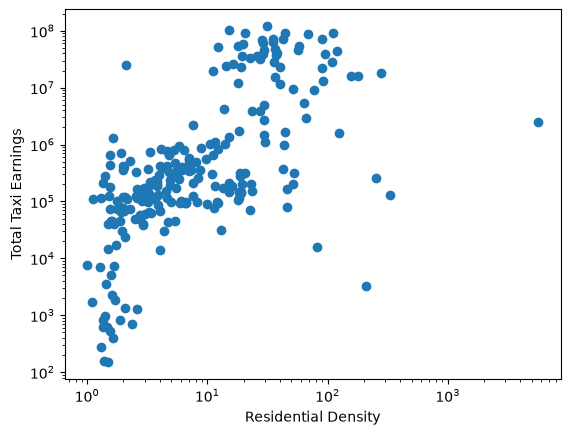

In [131]:
fig, axes = plt.subplots()
plt.scatter(demand_proxy_by_zone.select('residential_density').rdd.flatMap(lambda x: x).collect(),
            demand_proxy_by_zone.select('total_amount').rdd.flatMap(lambda x: x).collect())
plt.xlabel('Residential Density')
plt.ylabel('Total Taxi Earnings')
plt.yscale('log')  # Log scale for better visualization
plt.xscale('log')  # Log scale for better visualization
plt.show()

In [132]:
# calculate correlation between log(residential_density) and log(total_amount)
correlation = demand_proxy_by_zone.select(
    F.log(F.col('residential_density')).alias('log_density'),
    F.log(F.col('total_amount')).alias('log_amount')
).corr('log_density', 'log_amount')

print(f"Correlation: {correlation}")

Correlation: 0.6449368584584199


In [133]:
boroughs = sorted(demand_proxy_by_zone.select('Borough').distinct().rdd.map(lambda row: row[0]).collect())
borough_data_list = []

for borough in boroughs:
    borough_data = demand_proxy_by_zone.filter(demand_proxy_by_zone['Borough'] == borough)
    density_values = borough_data.select('residential_density').rdd.flatMap(lambda x: x).collect()
    borough_data_list.append(density_values)


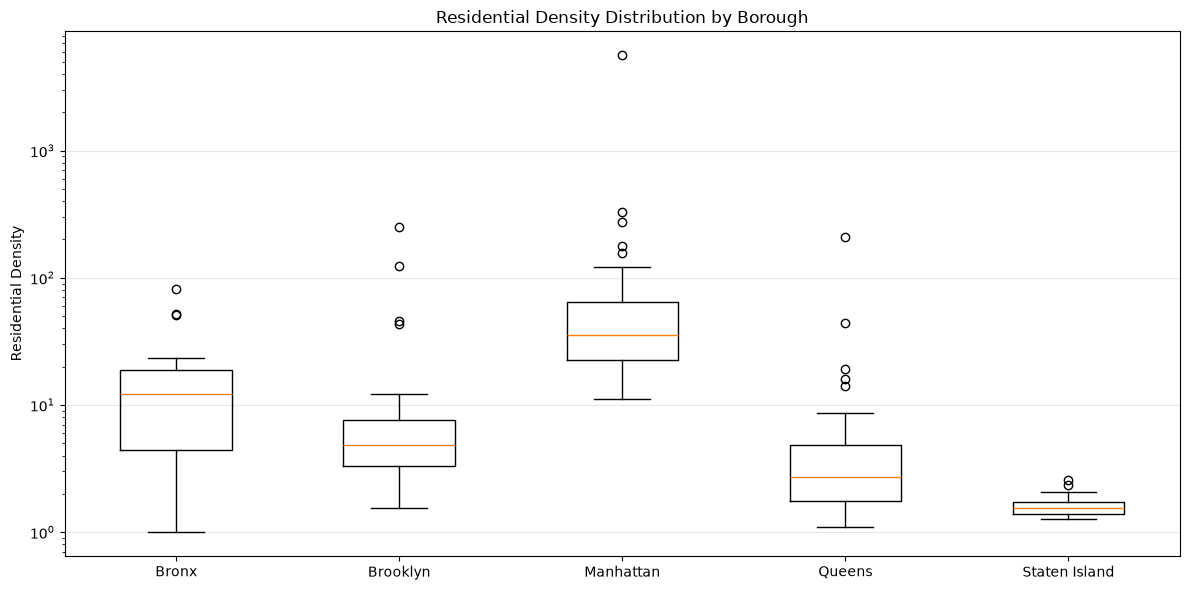

In [134]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(borough_data_list, label=boroughs)
ax.set_xticklabels(boroughs)
ax.set_ylabel('Residential Density')
ax.set_yscale('log')
ax.set_title('Residential Density Distribution by Borough')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()